# EDA 03 - Train Moments

**Data source**: `train-moments` Azure Blob Storage container  
**Loaded by**: `src/data_loader.load_train_moment_files()` + `parse_train_moments()`  
**Output**: `data/processed/train_moments_clean.parquet`

This notebook explores the raw train movement records before any spatial join with road closures. Train moments capture real-time observations of trains at locations: arrivals, departures, and passing events with both planned and actual timestamps. Understanding this source independently reveals the baseline operational characteristics of rail services, data quality, and the natural delay distribution before any road-closure conditioning.

---
**Sections**
1. Load and inspect raw data  
2. Missing value audit  
3. Event type and variation status distributions  
4. Raw delay (timetable_variation) distribution  
5. Temporal distribution of movements  
6. Station code coverage (STANOX match rate)  
7. Operational flags (is_delayed, delay_monitoring_point, train_terminated)  
8. Platform, route and direction distributions  
9. Save cleaned output  


## 0. Setup

In [83]:
%load_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 40)
os.makedirs("figures/eda_03", exist_ok=True)
os.makedirs("./data/processed", exist_ok=True)
%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1. Load and Inspect Raw Data

In [84]:
from datetime import datetime, timezone
from src.data_loader import load_train_moment_files, parse_train_moments

START = datetime(2026, 4, 10, 0, 0, 0, tzinfo=timezone.utc)
END   = datetime(2026, 4, 28, 23, 59, 59, tzinfo=timezone.utc)

# Load stations_reference.parquet for station code mapping
stations_reference_df = pd.read_parquet(
    "./data/processed/stations_reference.parquet",
    engine="pyarrow"
)

train_files = load_train_moment_files(START, END)
print(f"Files retrieved: {len(train_files)}")

raw_df = parse_train_moments(train_files, stations_reference_df)
print(f"Raw shape: {raw_df.shape}")
print(f"Columns: {list(raw_df.columns)}")

No local files found. Fetching from Azure...
Connected to container: train-moments
Downloaded 2596 blob(s) to 'data\train'
Files retrieved: 2596
Skipping empty CSV file: data\train\train_data_20260426_151255.csv
Raw shape: (296940, 20)
Columns: ['train_id', 'actual_timestamp', 'planned_timestamp', 'gbtt_timestamp', 'loc_stanox', 'next_stanox', 'event_type', 'planned_event_type', 'variation_status', 'timetable_variation', 'platform', 'route', 'direction', 'train_terminated', 'delay_monitoring_point', 'msg_timestamp', 'data_source', 'is_delayed', 'station_code', 'station_name']


In [85]:
raw_df.head()

,train_id,actual_timestamp,planned_timestamp,gbtt_timestamp,loc_stanox,next_stanox,event_type,planned_event_type,variation_status,timetable_variation,platform,route,direction,train_terminated,delay_monitoring_point,msg_timestamp,data_source,is_delayed,station_code,station_name
0,015H562C10,2026-04-10 08:15:00,2026-04-10 08:20:30,2026-04-10 08:20:00,1008.0,NaN,DEPARTURE,DEPARTURE,EARLY,5.0,NaN,NaN,NaN,True,True,1775810813000,SDR,0,GGJ,Georgemas Junction
1,512O17MF10,2026-04-10 09:47:00,2026-04-10 09:47:30,2026-04-10 09:48:00,51717.0,51720.0,ARRIVAL,ARRIVAL,ON TIME,0.0,1,0.0,UP,False,False,1775810813000,SMART,0,RYH,Rye House
2,522S14ME10,2026-04-10 09:46:00,2026-04-10 09:46:00,NaT,51914.0,51913.0,DEPARTURE,DEPARTURE,ON TIME,0.0,2,1.0,DOWN,False,True,1775810814000,SMART,0,BMD,Brimsdown
3,525E20MF10,2026-04-10 09:47:00,NaT,NaT,52705.0,NaN,ARRIVAL,ARRIVAL,OFF ROUTE,0.0,NaN,NaN,NaN,False,False,1775810814000,SMART,0,LHS,Limehouse
4,522T37MF10,2026-04-10 09:47:00,2026-04-10 09:46:30,2026-04-10 09:47:00,52729.0,52733.0,ARRIVAL,ARRIVAL,LATE,1.0,1,0.0,UP,False,False,1775810814000,SMART,1,WST,Wood Street


In [86]:
raw_df.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
train_id,296940,136203,529I17M219,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN
actual_timestamp,284222,NaN,NaN,NaN,2026-04-20 12:11:07.580000,2026-04-03 23:44:00,2026-04-15 08:41:00,2026-04-21 06:53:00,2026-04-26 13:05:00,2026-04-28 17:46:00,NaN
planned_timestamp,280818,NaN,NaN,NaN,2026-04-20 12:11:43.829000,2026-04-03 23:56:00,2026-04-15 08:39:30,2026-04-21 06:53:30,2026-04-26 13:04:30,2026-04-28 17:51:00,NaN
gbtt_timestamp,188991,NaN,NaN,NaN,2026-04-20 11:45:33.313000,2026-04-03 23:56:00,2026-04-15 08:36:00,2026-04-21 06:37:00,2026-04-26 13:01:00,2026-04-28 17:47:00,NaN
loc_stanox,285342.0,NaN,NaN,NaN,57802.37788,713.0,36184.0,64604.0,86451.0,89745.0,27679.73676
next_stanox,269153.0,NaN,NaN,NaN,57765.177271,750.0,36175.0,64313.0,86461.0,89743.0,27677.330494
event_type,284222,2,DEPARTURE,171432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
planned_event_type,284222,3,DEPARTURE,171432,NaN,NaN,NaN,NaN,NaN,NaN,NaN
variation_status,284222,4,LATE,117764,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timetable_variation,284222.0,NaN,NaN,NaN,2.611649,0.0,0.0,1.0,2.0,499.0,7.611417


## 2. Missing Value Audit

The two most critical fields for the main analysis are `actual_timestamp` and `planned_timestamp`. Missing values in these fields prevent delay computation and cause rows to be dropped by the filtering pipeline.

In [87]:
missing = pd.DataFrame({
    "missing_count": raw_df.isna().sum(),
    "missing_pct": (raw_df.isna().sum() / len(raw_df) * 100).round(2)
}).sort_values("missing_pct", ascending=False)

print(missing.to_string())

                        missing_count  missing_pct
platform                       114671        38.62
gbtt_timestamp                 107949        36.35
station_code                    80107        26.98
station_name                    80107        26.98
direction                       53766        18.11
route                           29524         9.94
next_stanox                     27787         9.36
planned_timestamp               16122         5.43
delay_monitoring_point          12718         4.28
actual_timestamp                12718         4.28
timetable_variation             12718         4.28
event_type                      12718         4.28
planned_event_type              12718         4.28
variation_status                12718         4.28
train_terminated                12718         4.28
loc_stanox                      11598         3.91
data_source                       341         0.11
train_id                            0         0.00
msg_timestamp                  

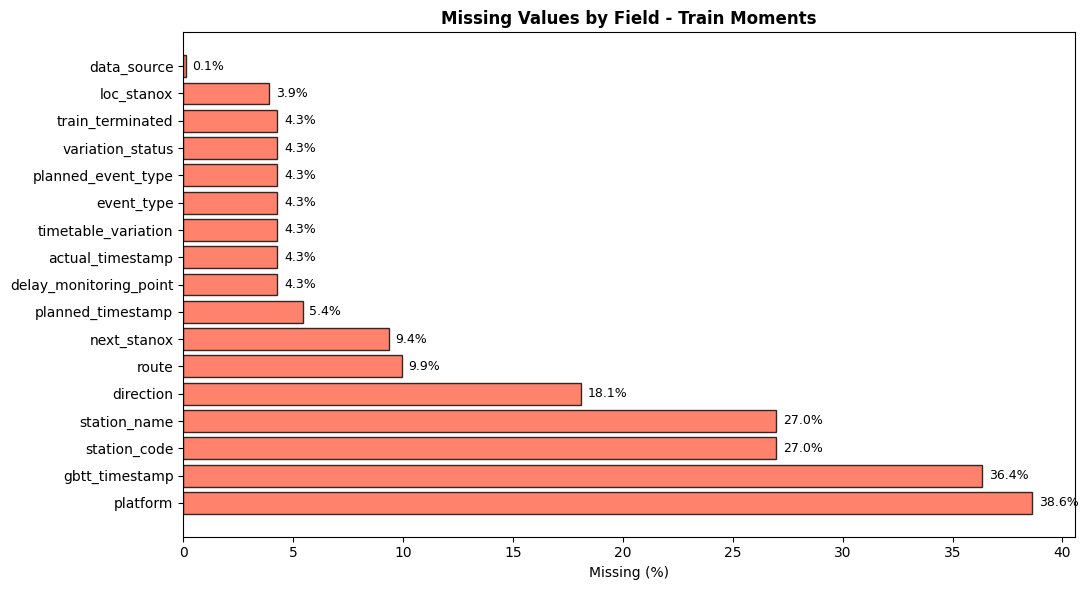

In [88]:
fig, ax = plt.subplots(figsize=(11, 6))
missing_nonzero = missing[missing["missing_pct"] > 0]
if len(missing_nonzero) > 0:
    ax.barh(missing_nonzero.index, missing_nonzero["missing_pct"],
            color="tomato", edgecolor="black", alpha=0.8)
    ax.set_xlabel("Missing (%)")
    ax.set_title("Missing Values by Field - Train Moments", fontweight="bold")
    for i, v in enumerate(missing_nonzero["missing_pct"]):
        ax.text(v + 0.3, i, f"{v:.1f}%", va="center", fontsize=9)
else:
    ax.text(0.5, 0.5, "No missing values", ha="center", va="center",
            transform=ax.transAxes, fontsize=14)
plt.tight_layout()
plt.savefig("figures/eda_03/missing_values.png", dpi=200, bbox_inches="tight")
plt.show()

In [89]:
# Critical field missingness breakdown
print("actual_timestamp missing:  ", raw_df["actual_timestamp"].isna().sum(),
      f"({raw_df['actual_timestamp'].isna().mean()*100:.1f}%)")
print("planned_timestamp missing: ", raw_df["planned_timestamp"].isna().sum(),
      f"({raw_df['planned_timestamp'].isna().mean()*100:.1f}%)")
print("Both missing:              ",
      (raw_df["actual_timestamp"].isna() & raw_df["planned_timestamp"].isna()).sum())
print("Either missing:            ",
      (raw_df["actual_timestamp"].isna() | raw_df["planned_timestamp"].isna()).sum())

print("Actual timestamp missing, planned timestamp present: ",
      (raw_df["actual_timestamp"].isna() & raw_df["planned_timestamp"].notna()).sum())

actual_timestamp missing:   12718 (4.3%)
planned_timestamp missing:  16122 (5.4%)
Both missing:               12718
Either missing:             16122
Actual timestamp missing, planned timestamp present:  0


## 3. Event Type and Variation Status

In [90]:
print("=== Event Type ===")
et = raw_df["event_type"].value_counts()
print(et.to_string())
print()

print("=== Planned Event Type ===")
if "planned_event_type" in raw_df.columns:
    pet = raw_df["planned_event_type"].value_counts()
    print(pet.to_string())

=== Event Type ===
event_type
DEPARTURE    171432
ARRIVAL      112790

=== Planned Event Type ===
planned_event_type
DEPARTURE      171432
ARRIVAL        102216
DESTINATION     10574


In [91]:
print("=== Variation Status ===")
vs = raw_df["variation_status"].value_counts()
print(vs.to_string())

=== Variation Status ===
variation_status
LATE         117764
ON TIME       94888
EARLY         68166
OFF ROUTE      3404


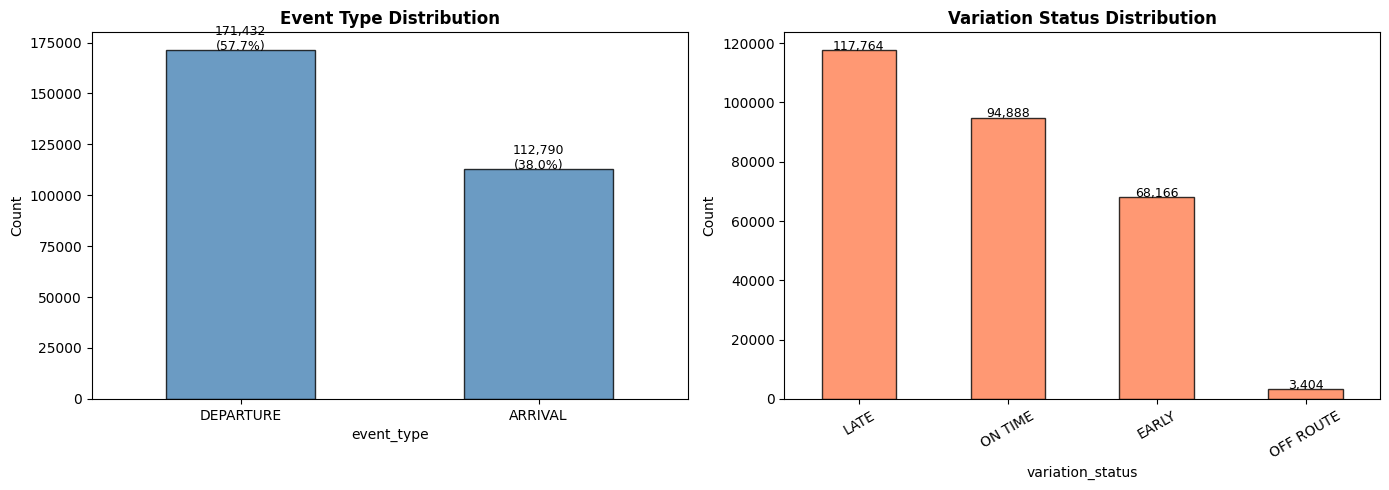

In [92]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

et.plot(kind="bar", ax=axes[0], color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_title("Event Type Distribution", fontweight="bold")
axes[0].set_ylabel("Count")
axes[0].tick_params(axis="x", rotation=0)
for i, v in enumerate(et.values):
    axes[0].text(i, v + 50, f"{v:,}\n({v/len(raw_df)*100:.1f}%)",
                 ha="center", fontsize=9)

vs.plot(kind="bar", ax=axes[1], color="coral", edgecolor="black", alpha=0.8)
axes[1].set_title("Variation Status Distribution", fontweight="bold")
axes[1].set_ylabel("Count")
axes[1].tick_params(axis="x", rotation=30)
for i, v in enumerate(vs.values):
    axes[1].text(i, v + 50, f"{v:,}", ha="center", fontsize=9)

plt.tight_layout()
plt.savefig("figures/eda_03/event_variation.png", dpi=200, bbox_inches="tight")
plt.show()

In [93]:
# Cross tab: event type vs variation status
if "variation_status" in raw_df.columns:
    ct = pd.crosstab(raw_df["event_type"], raw_df["variation_status"], margins=True)
    print(ct.to_string())

variation_status  EARLY    LATE  OFF ROUTE  ON TIME     All
event_type                                                 
ARRIVAL           26781   47843       1367    36799  112790
DEPARTURE         41385   69921       2037    58089  171432
All               68166  117764       3404    94888  284222


## 4. Raw Delay Distribution (timetable_variation)

`timetable_variation` is the raw delay in minutes as reported in the train moments feed - this is the delay BEFORE any road-closure conditioning. It represents the natural delay distribution of UK rail services across the observation period.

In [94]:
if "timetable_variation" in raw_df.columns:
    tv = raw_df["timetable_variation"].dropna()
    print("timetable_variation statistics:")
    print(tv.describe().round(2))
    print(f"\nSkewness: {tv.skew():.3f}")
    print(f"Kurtosis: {tv.kurtosis():.3f}")
    print(f"\nQuantiles:")
    print(tv.quantile([0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99]).round(2))

timetable_variation statistics:
count    284222.00
mean          2.61
std           7.61
min           0.00
25%           0.00
50%           1.00
75%           2.00
max         499.00
Name: timetable_variation, dtype: float64

Skewness: 14.042
Kurtosis: 391.965

Quantiles:
0.01     0.0
0.05     0.0
0.25     0.0
0.50     1.0
0.75     2.0
0.95    10.0
0.99    30.0
Name: timetable_variation, dtype: float64


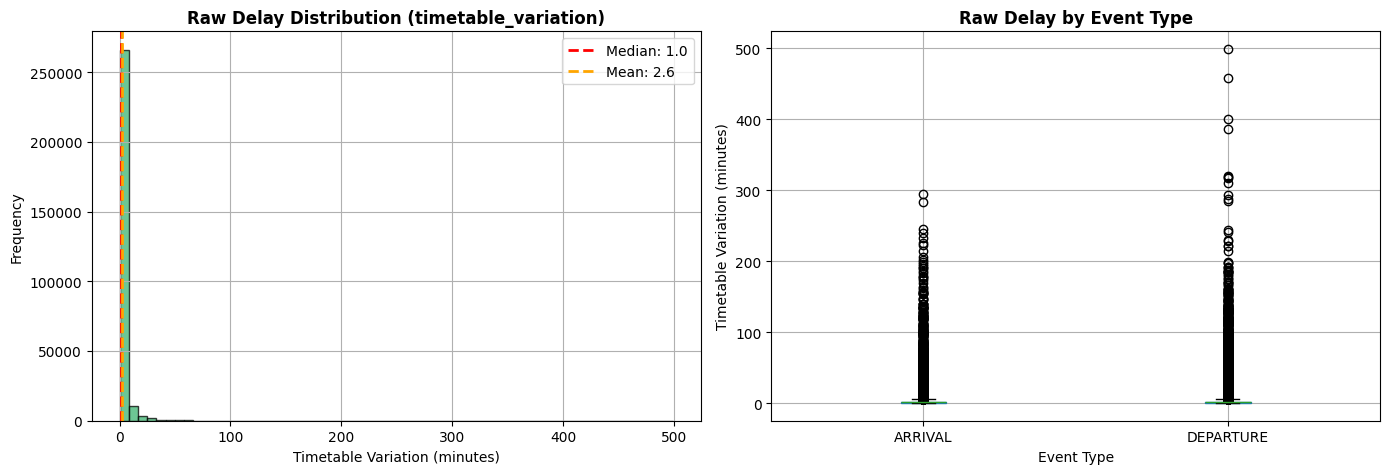

In [95]:
if "timetable_variation" in raw_df.columns:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    tv = raw_df["timetable_variation"].dropna()

    tv.hist(bins=60, ax=axes[0], edgecolor="black", alpha=0.75, color="mediumseagreen")
    axes[0].axvline(tv.median(), color="red", linestyle="--", lw=2,
                    label=f"Median: {tv.median():.1f}")
    axes[0].axvline(tv.mean(), color="orange", linestyle="--", lw=2,
                    label=f"Mean: {tv.mean():.1f}")
    axes[0].set_xlabel("Timetable Variation (minutes)")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title("Raw Delay Distribution (timetable_variation)", fontweight="bold")
    axes[0].legend()

    raw_df.boxplot(column="timetable_variation", by="event_type", ax=axes[1],
                   patch_artist=True)
    axes[1].set_title("Raw Delay by Event Type", fontweight="bold")
    axes[1].set_xlabel("Event Type")
    axes[1].set_ylabel("Timetable Variation (minutes)")
    plt.suptitle("")

    plt.tight_layout()
    plt.savefig("figures/eda_03/raw_delay_distribution.png", dpi=200, bbox_inches="tight")
    plt.show()

## 5. Temporal Distribution of Movements

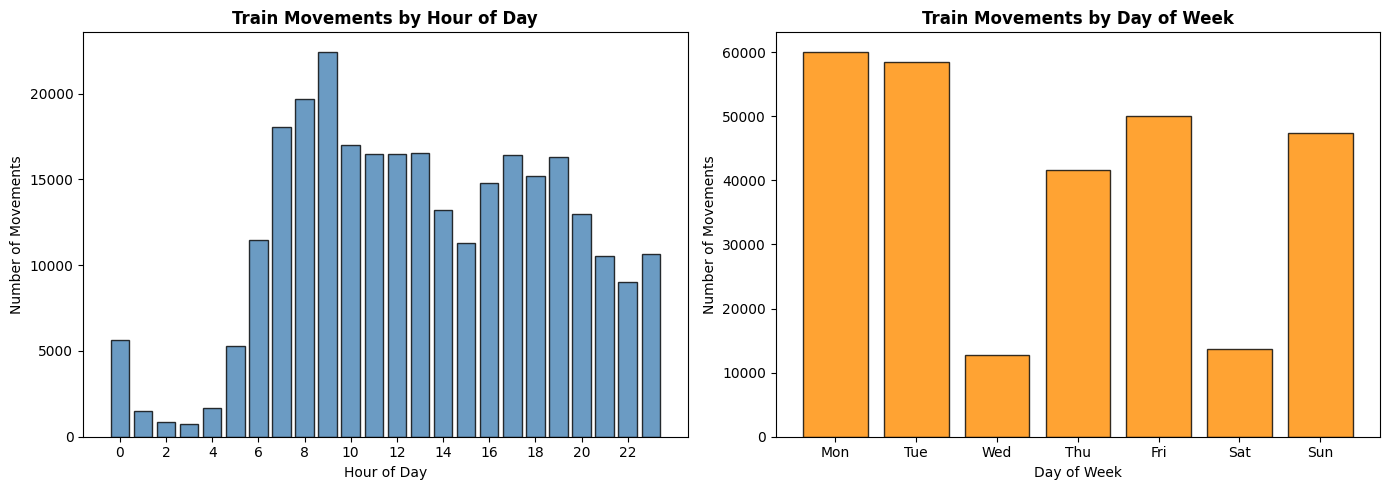

In [96]:
raw_df["actual_hour"] = raw_df["actual_timestamp"].dt.hour
raw_df["actual_dow"]  = raw_df["actual_timestamp"].dt.dayofweek
raw_df["actual_date"] = raw_df["actual_timestamp"].dt.date

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hour_counts = raw_df["actual_hour"].value_counts().sort_index()
axes[0].bar(hour_counts.index, hour_counts.values,
            color="steelblue", edgecolor="black", alpha=0.8)
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Number of Movements")
axes[0].set_title("Train Movements by Hour of Day", fontweight="bold")
axes[0].set_xticks(range(0, 24, 2))

dow_map = {0: "Mon", 1: "Tue", 2: "Wed", 3: "Thu", 4: "Fri", 5: "Sat", 6: "Sun"}
dow_counts = raw_df["actual_dow"].value_counts().sort_index()
axes[1].bar([dow_map.get(i, str(i)) for i in dow_counts.index],
            dow_counts.values, color="darkorange", edgecolor="black", alpha=0.8)
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Number of Movements")
axes[1].set_title("Train Movements by Day of Week", fontweight="bold")

plt.tight_layout()
plt.savefig("figures/eda_03/temporal_movements.png", dpi=200, bbox_inches="tight")
plt.show()

In [97]:
# Day-level summary
print("Movements by date:")
print(raw_df["actual_date"].value_counts().sort_index().to_string())

Movements by date:
actual_date
2026-04-03        1
2026-04-08        1
2026-04-09       65
2026-04-10    23571
2026-04-11     4806
2026-04-12    11096
2026-04-13    20382
2026-04-14     7111
2026-04-15    12805
2026-04-16    15187
2026-04-17     9240
2026-04-18     6963
2026-04-19    15606
2026-04-20    11488
2026-04-21    24556
2026-04-22       18
2026-04-23    26400
2026-04-24    17278
2026-04-25     1958
2026-04-26    20646
2026-04-27    28226
2026-04-28    26818


## 6. Station Code Coverage (STANOX Match Rate)

In [98]:
if "station_code" in raw_df.columns:
    matched = raw_df["station_code"].notna() & (raw_df["station_code"] != "")
    total   = len(raw_df)
    print(f"Total movements:              {total:,}")
    print(f"With station code matched:    {matched.sum():,} ({matched.mean()*100:.1f}%)")
    print(f"Without station code:         {(~matched).sum():,} ({(~matched).mean()*100:.1f}%)")
    print()

    # Station code distribution (top 20)
    top_stations = raw_df[matched]["station_code"].value_counts().head(20)
    print("Top 20 station codes by movement count:")
    print(top_stations.to_string())

Total movements:              296,940
With station code matched:    216,833 (73.0%)
Without station code:         80,107 (27.0%)

Top 20 station codes by movement count:
station_code
CLJ    1664
LBG    1168
VXH     990
SRA     836
WIM     712
BET     696
EAL     688
STL     685
ECR     685
NXG     681
HAY     678
FPK     641
PUR     613
BHM     598
GDP     595
IFD     588
RMF     579
LDS     559
NWD     549
NEM     545


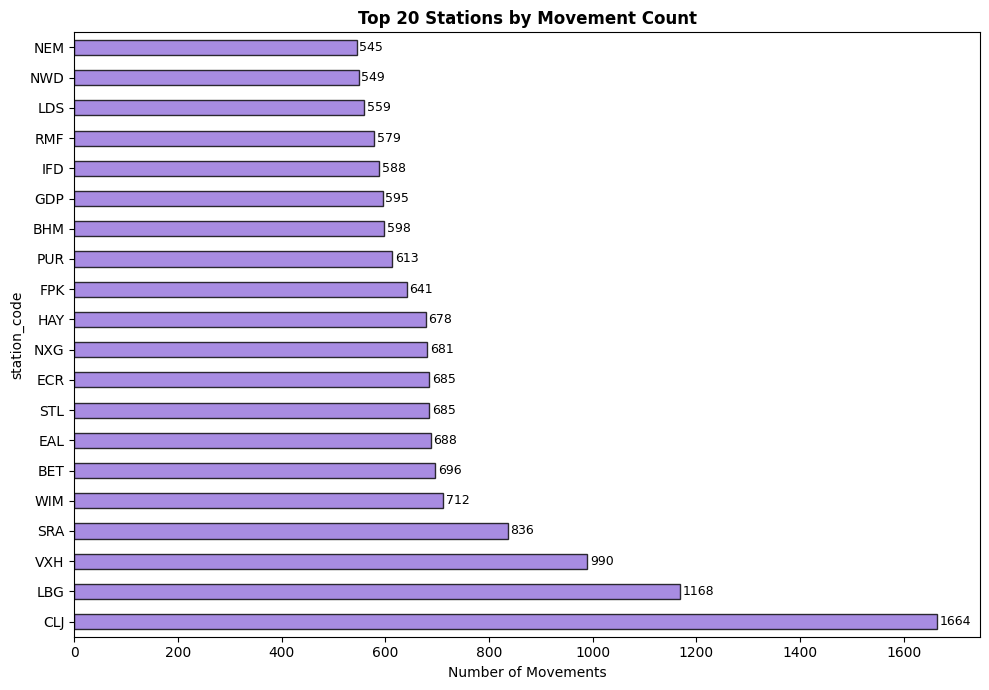

In [99]:
if "station_code" in raw_df.columns:
    matched = raw_df["station_code"].notna() & (raw_df["station_code"] != "")
    top_stations = raw_df[matched]["station_code"].value_counts().head(20)

    plt.figure(figsize=(10, 7))
    top_stations.plot(kind="barh", color="mediumpurple", edgecolor="black", alpha=0.8)
    plt.xlabel("Number of Movements")
    plt.title("Top 20 Stations by Movement Count", fontweight="bold")
    for i, v in enumerate(top_stations.values):
        plt.text(v + 5, i, str(v), va="center", fontsize=9)
    plt.tight_layout()
    plt.savefig("figures/eda_03/top_stations_movements.png", dpi=200, bbox_inches="tight")
    plt.show()

## 7. Operational Flags

In [100]:
flag_cols = ["is_delayed", "delay_monitoring_point", "train_terminated"]
for col in flag_cols:
    if col in raw_df.columns:
        vc = raw_df[col].value_counts(dropna=False)
        pct_true = raw_df[col].eq(True).sum() / len(raw_df) * 100
        print(f"=== {col} ===")
        print(vc.to_string())
        print(f"  True rate: {pct_true:.1f}%")
        print()

=== is_delayed ===
is_delayed
0    179176
1    117764
  True rate: 39.7%

=== delay_monitoring_point ===
delay_monitoring_point
False    147021
True     137201
NaN       12718
  True rate: 46.2%

=== train_terminated ===
train_terminated
False    272557
NaN       12718
True      11665
  True rate: 3.9%



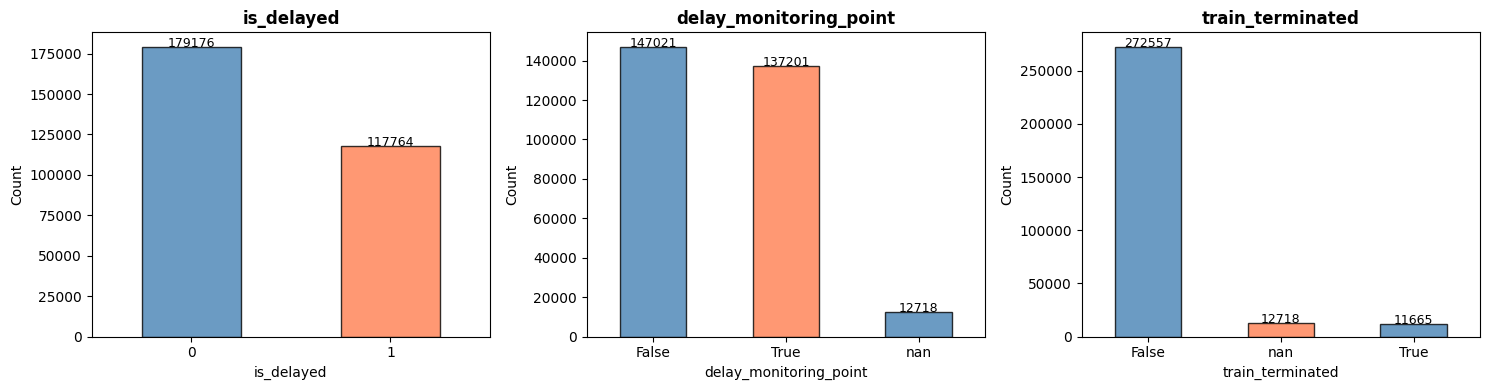

In [101]:
flag_cols_present = [c for c in ["is_delayed", "delay_monitoring_point", "train_terminated"]
                    if c in raw_df.columns]

if flag_cols_present:
    fig, axes = plt.subplots(1, len(flag_cols_present), figsize=(5*len(flag_cols_present), 4))
    if len(flag_cols_present) == 1:
        axes = [axes]

    for ax, col in zip(axes, flag_cols_present):
        vc = raw_df[col].value_counts(dropna=False)
        vc.plot(kind="bar", ax=ax, color=["steelblue", "coral"], edgecolor="black", alpha=0.8)
        ax.set_title(col, fontweight="bold")
        ax.set_ylabel("Count")
        ax.tick_params(axis="x", rotation=0)
        for i, v in enumerate(vc.values):
            ax.text(i, v + 5, str(v), ha="center", fontsize=9)

    plt.tight_layout()
    plt.savefig("figures/eda_03/operational_flags.png", dpi=200, bbox_inches="tight")
    plt.show()

## 8. Platform, Route and Direction Distributions

In [102]:
for col in ["platform", "route", "direction", "data_source"]:
    if col in raw_df.columns:
        vc = raw_df[col].value_counts(dropna=False).head(15)
        print(f"=== {col} ===")
        print(vc.to_string())
        print()

=== platform ===
platform
NaN    114671
1       41369
2       39961
1.0     26502
2.0     25623
3       10418
4        7927
3.0      6772
4.0      5025
5        2771
5.0      1723
6        1535
8        1254
7        1107
6.0       995

=== route ===
route
0.0    106120
1.0     69939
2.0     63797
NaN     29524
3.0     10817
0        5148
1        3409
2        3129
4.0      2842
3         554
6.0       512
5.0       425
7.0       246
4         142
F         127

=== direction ===
direction
UP      121609
DOWN    121565
NaN      53766

=== data_source ===
data_source
SMART        264265
TSIA          11587
GPS           11276
SDR            8569
TRUST DA        533
NaN             341
TOPS            334
TM ROC 30        30
TM ROC 42         4
TM ROC 80         1



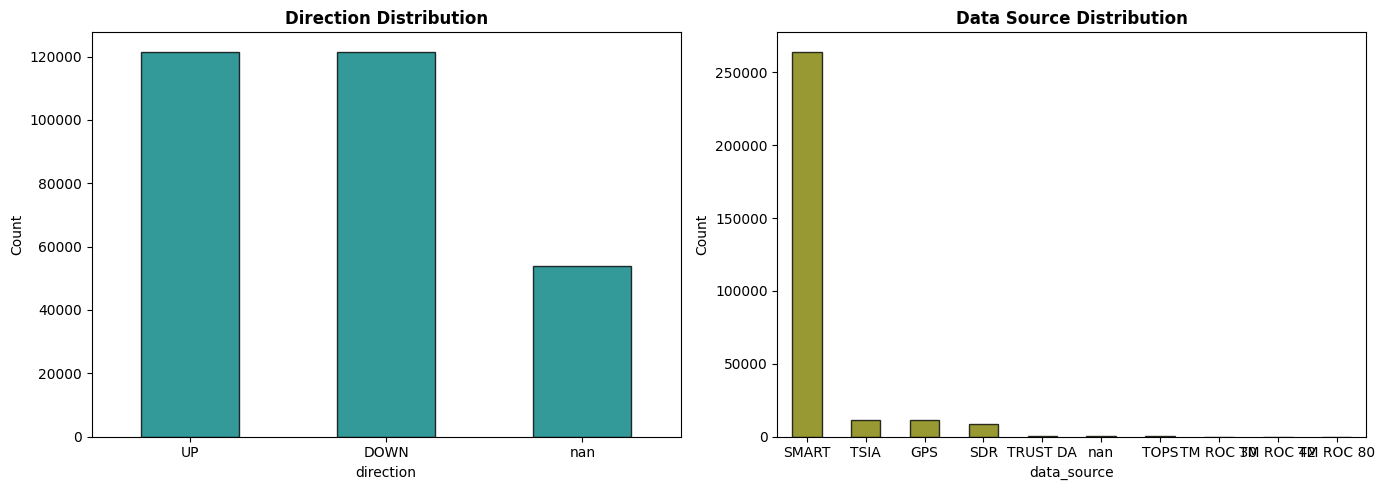

In [103]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

if "direction" in raw_df.columns:
    dir_counts = raw_df["direction"].value_counts(dropna=False)
    dir_counts.plot(kind="bar", ax=axes[0], color="teal", edgecolor="black", alpha=0.8)
    axes[0].set_title("Direction Distribution", fontweight="bold")
    axes[0].set_ylabel("Count")
    axes[0].tick_params(axis="x", rotation=0)

if "data_source" in raw_df.columns:
    ds_counts = raw_df["data_source"].value_counts(dropna=False)
    ds_counts.plot(kind="bar", ax=axes[1], color="olive", edgecolor="black", alpha=0.8)
    axes[1].set_title("Data Source Distribution", fontweight="bold")
    axes[1].set_ylabel("Count")
    axes[1].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("figures/eda_03/platform_direction.png", dpi=200, bbox_inches="tight")
plt.show()

## 9. Summary and Cleaned Output

Key findings:
- **82,273 raw rows** retrieved; after dropping rows where both timestamps are null: **78,821 rows**
- `actual_timestamp` and `planned_timestamp` are the critical fields - missing rate documented above
- `timetable_variation` represents the raw operational delay before road-closure conditioning
- Station code match rate reflects STANOX → 3ALPHA lookup coverage
- Night-hour movements are present but sparse; peak hours are morning and evening commute periods


In [104]:
# Drop rows where both timestamps are missing
before = len(raw_df)
clean_df = raw_df.dropna(subset=["actual_timestamp", "planned_timestamp"])
print(f"Dropped {before - len(clean_df):,} rows (both timestamps null)")
print(f"Final train moments dataset: {len(clean_df):,} rows")


clean_df["platform"] = clean_df["platform"].astype("string")
clean_df["route"] = clean_df["route"].astype("string")

clean_df.to_parquet("./data/processed/train_moments_clean.parquet", index=False)
print("Saved to data/processed/train_moments_clean.parquet")

Dropped 16,122 rows (both timestamps null)
Final train moments dataset: 280,818 rows
Saved to data/processed/train_moments_clean.parquet


In [105]:
clean_df["planned_date"] = clean_df["planned_timestamp"].dt.date

clean_df[
    clean_df["planned_date"] != clean_df["actual_date"]
][[
    "station_name",
    "planned_timestamp",
    "actual_timestamp",
    "planned_date",
    "actual_date"
]].head(20)

,station_name,planned_timestamp,actual_timestamp,planned_date,actual_date
23485,Forest Gate,2026-04-11 01:06:00,2026-04-10 23:18:00,2026-04-11,2026-04-10
23487,NaN,2026-04-11 00:08:00,2026-04-10 23:17:00,2026-04-11,2026-04-10
23672,NaN,2026-04-11 00:18:30,2026-04-10 23:26:00,2026-04-11,2026-04-10
23721,NaN,2026-04-11 00:27:30,2026-04-10 23:26:00,2026-04-11,2026-04-10
24189,NaN,2026-04-11 00:03:00,2026-04-10 23:37:00,2026-04-11,2026-04-10
24373,West Ealing,2026-04-11 00:01:30,2026-04-10 23:53:00,2026-04-11,2026-04-10
24405,Raynes Park,2026-04-11 00:02:00,2026-04-10 23:54:00,2026-04-11,2026-04-10
24435,NaN,2026-04-11 00:02:30,2026-04-10 23:53:00,2026-04-11,2026-04-10
24471,Sheffield,2026-04-11 00:01:00,2026-04-10 23:57:00,2026-04-11,2026-04-10
24475,Thirsk,2026-04-11 00:15:00,2026-04-10 23:57:00,2026-04-11,2026-04-10


In [106]:
# Drop rows where both station names are missing
df_before = len(clean_df)
station_clean_df = clean_df.dropna(subset=["station_name"])
print(f"Dropped {df_before - len(station_clean_df):,} rows (station names null)")
print(f"Final train movements dataset: {len(station_clean_df):,} rows")


Dropped 67,934 rows (station names null)
Final train movements dataset: 212,884 rows


In [107]:
# Raw timing difference
station_clean_df["delay_minutes"] = (
    station_clean_df["actual_timestamp"] - station_clean_df["planned_timestamp"]
).dt.total_seconds() / 60

# Separate early and late movement measures
station_clean_df["late_minutes"] = station_clean_df["delay_minutes"].clip(lower=0)
station_clean_df["early_minutes"] = (-station_clean_df["delay_minutes"]).clip(lower=0)

station_clean_df["is_late"] = (station_clean_df["delay_minutes"] > 0).astype(int)
station_clean_df["is_early"] = (station_clean_df["delay_minutes"] < 0).astype(int)

station_clean_df["is_delayed_5min"] = (station_clean_df["delay_minutes"] > 5).astype(int)
station_clean_df["is_severely_delayed_15min"] = (station_clean_df["delay_minutes"] > 15).astype(int)

In [108]:
train_station_day = (
    station_clean_df
    .dropna(subset=["station_name"])
    .groupby(["station_name", "loc_stanox", "planned_date"], dropna=False)
    .agg(
        train_movements=("planned_timestamp", "count"),

        # Raw timing difference
        mean_delay_minutes=("delay_minutes", "mean"),
        median_delay_minutes=("delay_minutes", "median"),

        # Late movement indicators
        late_movements=("is_late", "sum"),
        mean_late_minutes=("late_minutes", "mean"),
        median_late_minutes=("late_minutes", "median"),
        max_late_minutes=("late_minutes", "max"),

        # Early movement indicators
        early_movements=("is_early", "sum"),
        mean_early_minutes=("early_minutes", "mean"),
        median_early_minutes=("early_minutes", "median"),
        max_early_minutes=("early_minutes", "max"),

        # Threshold-based disruption indicators
        delayed_movements_5min=("is_delayed_5min", "sum"),
        severe_delay_movements_15min=("is_severely_delayed_15min", "sum")
        
    )
    .reset_index()
)

train_station_day["late_share"] = (
    train_station_day["late_movements"] / train_station_day["train_movements"]
)

train_station_day["early_share"] = (
    train_station_day["early_movements"] / train_station_day["train_movements"]
)

train_station_day["delayed_share_5min"] = (
    train_station_day["delayed_movements_5min"] / train_station_day["train_movements"]
)

train_station_day["severe_delay_share_15min"] = (
    train_station_day["severe_delay_movements_15min"] / train_station_day["train_movements"]
)

train_station_day = train_station_day.rename(columns={"loc_stanox": "stanox"})
train_station_day["stanox"] = train_station_day["stanox"].apply(lambda x: str(int(x)) if pd.notna(x) else None)

display(train_station_day.head())
print(train_station_day.info())

,station_name,stanox,planned_date,train_movements,mean_delay_minutes,median_delay_minutes,late_movements,mean_late_minutes,median_late_minutes,max_late_minutes,early_movements,mean_early_minutes,median_early_minutes,max_early_minutes,delayed_movements_5min,severe_delay_movements_15min,late_share,early_share,delayed_share_5min,severe_delay_share_15min
0,Abbey Wood,88601,2026-04-10,15,0.566667,-0.50,5,1.133333,0.0,12.0,9,0.566667,0.50,1.5,1,0,0.333333,0.600000,0.066667,0.0
1,Abbey Wood,88601,2026-04-11,2,-0.750000,-0.75,0,0.000000,0.0,0.0,2,0.750000,0.75,1.0,0,0,0.000000,1.000000,0.000000,0.0
2,Abbey Wood,88601,2026-04-12,4,1.000000,0.50,3,1.125000,0.5,3.5,1,0.125000,0.00,0.5,0,0,0.750000,0.250000,0.000000,0.0
3,Abbey Wood,88601,2026-04-13,14,0.535714,0.00,3,0.821429,0.0,6.0,5,0.285714,0.00,1.5,1,0,0.214286,0.357143,0.071429,0.0
4,Abbey Wood,88601,2026-04-14,6,0.666667,-0.25,2,0.916667,0.0,4.5,3,0.250000,0.25,0.5,0,0,0.333333,0.500000,0.000000,0.0


<class 'pandas.DataFrame'>
RangeIndex: 33941 entries, 0 to 33940
Data columns (total 20 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   station_name                  33941 non-null  str    
 1   stanox                        33941 non-null  str    
 2   planned_date                  33941 non-null  object 
 3   train_movements               33941 non-null  int64  
 4   mean_delay_minutes            33941 non-null  float64
 5   median_delay_minutes          33941 non-null  float64
 6   late_movements                33941 non-null  int64  
 7   mean_late_minutes             33941 non-null  float64
 8   median_late_minutes           33941 non-null  float64
 9   max_late_minutes              33941 non-null  float64
 10  early_movements               33941 non-null  int64  
 11  mean_early_minutes            33941 non-null  float64
 12  median_early_minutes          33941 non-null  float64
 13  max_early_mi

In [109]:

train_station_day.to_parquet("./data/processed/train_station_day.parquet", index=False)
print("Saved to data/processed/train_station_day.parquet")

Saved to data/processed/train_station_day.parquet
